In [24]:
import sys
import os 
import pandas as pd
import numpy as np
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.analysis.sensitivity import SensitivityAnalyzer
from omegaconf import OmegaConf

In [71]:
parameter_ranges = OmegaConf.load('../param_config.yaml')
dependent_parameter_names = ['Pc_des']
dependent_parameters = [{'parameter_name': 'Pc_des', 'function': lambda Pa_des : Pa_des - 20000, 'dependent_param': 'Pa_des'}]

SA = SensitivityAnalyzer(parameter_ranges, dependent_parameter_names=None, method='sobol', seed=42, N=1024 , calculate_second_order=True)

SA.generate_samples()
SA.rescale_samples()
samples = SA.apply_dependent_parameters(dependent_parameters)
samples

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,Pc_des
0,345.931298,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,248431.866782
1,350.820492,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,248431.866782
2,345.931298,201919.596742,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,181919.596742
3,345.931298,268431.866782,1.789658,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,248431.866782
4,345.931298,268431.866782,2.632068,0.145910,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,248431.866782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28667,340.898636,152452.823874,1.307282,0.283673,0.728948,1.93546,0.292262,0.227824,3,0.000005,56.300426,20.085051,2.250420,132452.823874
28668,340.898636,152452.823874,1.307282,0.283673,0.728948,1.93546,0.292262,0.227824,3,0.000002,20.832063,20.085051,2.250420,132452.823874
28669,340.898636,152452.823874,1.307282,0.283673,0.728948,1.93546,0.292262,0.227824,3,0.000002,56.300426,31.383792,2.250420,132452.823874
28670,340.898636,152452.823874,1.307282,0.283673,0.728948,1.93546,0.292262,0.227824,3,0.000002,56.300426,20.085051,0.862373,132452.823874


In [90]:
dejvis = samples[0:15000]
camila = samples[15000:21836]
nathaly = samples[21836:]

In [7]:
print(f'dejvis {dejvis.shape}, camila {camila.shape}, nathaly {nathaly.shape}')

dejvis (15000, 14), camila (6836, 14), nathaly (6836, 14)


In [13]:
alphapem_path = r"D:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\external\AlphaPEM"
sys.path.append(alphapem_path)

In [42]:
all_compl = pd.read_pickle("../sampling_test/all_samples.pkl")
all_compl = all_compl[parameter_ranges.keys()]
print(f'allcmpl: {all_compl.shape}')

allcmpl: (28672, 13)


In [ ]:
all_dejvis = pd.read_pickle("../sampling_test/dejvis15000.pkl")
print(f'all_dejvis: {all_compl.shape}')
all_dejvis_15_cmpl = all_dejvis.iloc[:15000,:]
all_dejvis_15 = all_dejvis_15_cmpl[parameter_ranges.keys()]
print(f'all_dejvis: {all_dejvis_15.shape}')

all_camila_cmpl = pd.read_pickle("../sampling_test/camila6836.pkl")
all_camila = all_camila_cmpl[parameter_ranges.keys()]
print(f'all_camila: {all_camila.shape}')
all_nathaly_cmpl = pd.read_pickle("../sampling_test/nathaly6836.pkl")
all_nathaly = all_nathaly_cmpl[parameter_ranges.keys()]
print(f'all_nathaly: {all_nathaly.shape}')

all_dejvis: (28672, 13)
all_dejvis: (15000, 13)
all_camila: (6836, 13)
all_nathaly: (6836, 13)


In [74]:
pd.set_option('display.max_columns', None)
dejvis.head(2)

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,Pc_des
0,345.931298,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.95271,248431.866782
1,350.820492,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.95271,248431.866782


In [91]:
import numpy as np
dejvis = dejvis.drop('Pc_des',axis=1)
all_equal_dejvis = np.array_equal(dejvis.values, all_dejvis_15.values)
print("Dejvis: All values equal:" if all_equal_dejvis else "Values differ")
camila = camila.drop('Pc_des',axis=1)
all_equal_camila = np.array_equal(camila.values, all_camila.values)
print("Camila: All values equal:" if all_equal_camila else "Values differ")
nathaly = nathaly.drop('Pc_des',axis=1)
all_equal_nathaly = np.array_equal(nathaly.values, all_nathaly.values)
print("Nathaly: All values equal:" if all_equal_nathaly else "Values differ")


Dejvis: All values equal:
Camila: All values equal:
Values differ


Zoom-in the third chunk of samples

In [96]:
nathaly.head(3)

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c
21836,355.382794,160337.531859,2.46772,0.455907,0.744422,1.757421,0.183778,0.178333,5,0.000002,70.700643,15.762654,1.069481
21837,355.382794,160337.531859,2.46772,0.455907,0.744422,1.757421,0.183778,0.178333,5,0.000002,59.312537,35.950055,1.069481
21838,355.382794,160337.531859,2.46772,0.455907,0.744422,1.757421,0.183778,0.178333,5,0.000002,59.312537,15.762654,0.898154


In [93]:
all_nathaly.head(3)

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c
0,340.209463,216303.601579,1.607255,0.425497,0.592501,1.921519,0.268225,0.169599,5,0.000005,16.507461,16.715486,1.040867
1,342.389576,174874.271563,2.347258,0.350594,0.794048,3.971394,0.399494,0.274027,3,0.000002,45.592812,32.860229,1.806489
2,358.904163,289790.453854,1.126193,0.289984,0.739764,1.894522,0.302205,0.166786,3,0.000003,75.592643,26.912362,1.088885


In [108]:
nathaly.shape

(6836, 13)

In [172]:
# Drop index to avoid index mismatches
common_rows = nathaly[nathaly.apply(tuple, axis=1).isin(all_nathaly.apply(tuple, axis=1))]

print("Matching rows:")
print(common_rows)


Matching rows:
              Tfc         Pa_des        Sc  Phi_c_des  epsilon_gdl       tau  \
21844  335.658305  277201.591579  2.584250   0.497627     0.572730  1.867062   
21850  335.658305  277201.591579  2.584250   0.233144     0.572730  1.867062   
21851  335.658305  277201.591579  2.584250   0.233144     0.572730  1.867062   
21853  335.658305  277201.591579  2.584250   0.233144     0.572730  1.867062   
21855  357.744220  277201.591579  2.140921   0.497627     0.796952  3.691955   
...           ...            ...       ...        ...          ...       ...   
28667  340.898636  152452.823874  1.307282   0.283673     0.728948  1.935460   
28668  340.898636  152452.823874  1.307282   0.283673     0.728948  1.935460   
28669  340.898636  152452.823874  1.307282   0.283673     0.728948  1.935460   
28670  340.898636  152452.823874  1.307282   0.283673     0.728948  1.935460   
28671  340.898636  152452.823874  1.307282   0.283673     0.728948  1.935460   

       epsilon_mc  epsil

In [109]:
6836-4450 

2386

In [ ]:
# List of indices in common
indices_to_check = common_rows.index.to_list()

# We check from the nathaly df what is the index in all_nathaly
matching_indices = {}

for idx in indices_to_check:
    row = nathaly.loc[idx]
    matches = (all_nathaly == row).all(axis=1)
    matched = all_nathaly.index[matches]
    matching_indices[idx] = list(matched) 

print(matching_indices)


{21844: [1804], 21850: [1800], 21851: [2250], 21853: [1324], 21855: [1272], 21859: [1409], 21862: [1313, 2309], 21867: [1313, 2309], 21868: [1608], 21869: [2293], 21873: [1370], 21877: [1608], 21880: [2295], 21881: [2056], 21886: [1119], 21887: [2090], 21890: [2188], 21895: [2188], 21897: [1264], 21899: [2311], 21901: [1939], 21909: [1555], 21911: [2415], 21915: [1215], 21916: [1345], 21918: [1664], 21920: [1858], 21923: [1664], 21924: [1544], 21927: [1763], 21929: [1362], 21931: [1193], 21932: [1325], 21936: [1914], 21937: [1050], 21938: [2474], 21958: [2153], 21960: [2405], 21968: [1060], 21971: [2483], 21985: [2423], 21992: [1455], 21993: [1673], 22003: [1699], 22004: [2006], 22005: [1052], 22008: [2459], 22013: [1979], 22015: [1143], 22017: [2218], 22021: [1877], 22024: [1977], 22032: [1841], 22034: [1551], 22035: [1453], 22044: [1581], 22046: [2086], 22052: [2012], 22053: [1043], 22057: [1936], 22063: [2315], 22064: [1906], 22066: [1095], 22067: [1756], 22069: [1225], 22075: [1083

In [232]:
indices_nathaly_all = [vals[0] for vals in matching_indices.values()]
print(f'how many dif indices_from coincide_rows {len(indices_nathaly_all)}')

how many dif indices_from coincide_rows 4450


In [233]:
len_rig =[len(vals) for vals in matching_indices.values()]
print(f'total indices in nathaly all {sum(len_rig) }') # It shows duplicates bcs it's larger than number of rows
print(f'the index with the max num of runs in nathaly_all {len_rig.index(6)}')

total indices in nathaly all 7206
the index with the max num of runs in nathaly_all 3128


In [ ]:
flat_list = [item for sublist in matching_indices.values() for item in sublist]
print(f'len {len(flat_list)}, len_unique {len(set(flat_list))}')

In [ ]:
subset = all_nathaly_cmpl.iloc[[1313, 2309]]
print(f"current coindice {np.sum(subset['ifc'].iloc[0] == subset['ifc'].iloc[1])}")
print(f"voltage coindice {np.sum(subset['Ucell'].iloc[0] == subset['Ucell'].iloc[1])}")

current coindice 31
voltage coindice 31


In [ ]:
subset = all_nathaly_cmpl.iloc[[736, 3748]]
print(f"current coindice {np.sum(subset['ifc'].iloc[0] == subset['ifc'].iloc[1])}")
print(f"voltage coindice {np.sum(subset['Ucell'].iloc[0] == subset['Ucell'].iloc[1])}")

current coindice 31
voltage coindice 31


In [253]:
subset = all_nathaly_cmpl.iloc[[885, 2586,5883]]
print(f"current coindice {np.sum(subset['ifc'].iloc[0] == subset['ifc'].iloc[1])}")
print(f"current coindice {np.sum(subset['ifc'].iloc[0] == subset['ifc'].iloc[2])}")
print(f"voltage coindice {np.sum(subset['Ucell'].iloc[0] == subset['Ucell'].iloc[1])}")
print(f"voltage coindice {np.sum(subset['Ucell'].iloc[0] == subset['Ucell'].iloc[2])}")

current coindice 31
current coindice 0
voltage coindice 31
voltage coindice 0


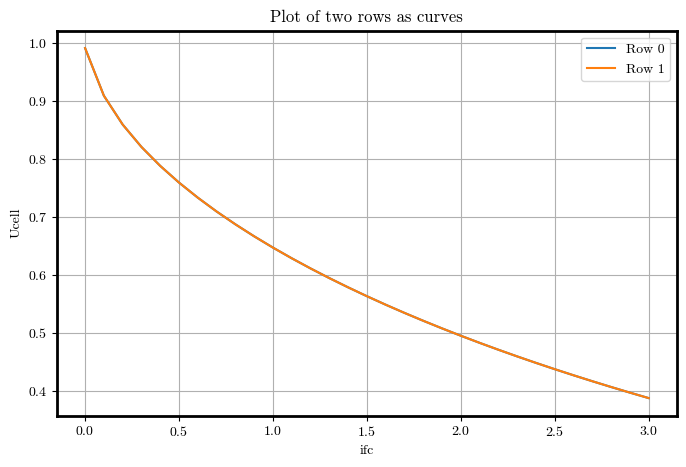

In [257]:
import matplotlib.pyplot as plt

x1 = subset.iloc[0]['ifc']
y1 = subset.iloc[0]['Ucell']

x2 = subset.iloc[1]['ifc']
y2 = subset.iloc[1]['Ucell']

plt.figure(figsize=(8,5))
plt.plot(x1, y1, label=f'Row {0}')
plt.plot(x2, y2, label=f'Row {1}')
plt.xlabel('ifc')
plt.ylabel('Ucell')
plt.title('Plot of two rows as curves')
plt.legend()
plt.grid(True)
plt.show()


In [231]:
# we filter the configuration that was run 6 times (the max)
key = list(matching_indices.keys())[3128]
value = matching_indices[key]
print(value)

[152, 798, 2386, 3832, 5514, 5519]


In [258]:
subset = all_nathaly_cmpl.iloc[[152, 798, 2386, 3832, 5514, 5519]]
print(f"current coindice {np.sum(subset['ifc'].iloc[0] == subset['ifc'].iloc[1])}")
print(f"current coindice {np.sum(subset['ifc'].iloc[0] == subset['ifc'].iloc[2])}")
print(f"current coindice {np.sum(subset['ifc'].iloc[0] == subset['ifc'].iloc[3])}")
print(f"current coindice {np.sum(subset['ifc'].iloc[0] == subset['ifc'].iloc[4])}")
print(f"current coindice {np.sum(subset['ifc'].iloc[0] == subset['ifc'].iloc[5])}")
print(f"current coindice {np.sum(subset['ifc'].iloc[4] == subset['ifc'].iloc[5])}")
print("..............")
print(f"voltage coindice {np.sum(subset['Ucell'].iloc[0] == subset['Ucell'].iloc[1])}")
print(f"voltage coindice {np.sum(subset['Ucell'].iloc[0] == subset['Ucell'].iloc[2])}")
print(f"voltage coindice {np.sum(subset['Ucell'].iloc[0] == subset['Ucell'].iloc[3])}")
print(f"voltage coindice {np.sum(subset['Ucell'].iloc[0] == subset['Ucell'].iloc[4])}")
print(f"voltage coindice {np.sum(subset['Ucell'].iloc[0] == subset['Ucell'].iloc[5])}")
print(f"voltage coindice {np.sum(subset['Ucell'].iloc[4] == subset['Ucell'].iloc[5])}")

current coindice 31
current coindice 31
current coindice 31
current coindice 0
current coindice 0
current coindice 31
..............
voltage coindice 31
voltage coindice 31
voltage coindice 31
voltage coindice 0
voltage coindice 0
voltage coindice 31


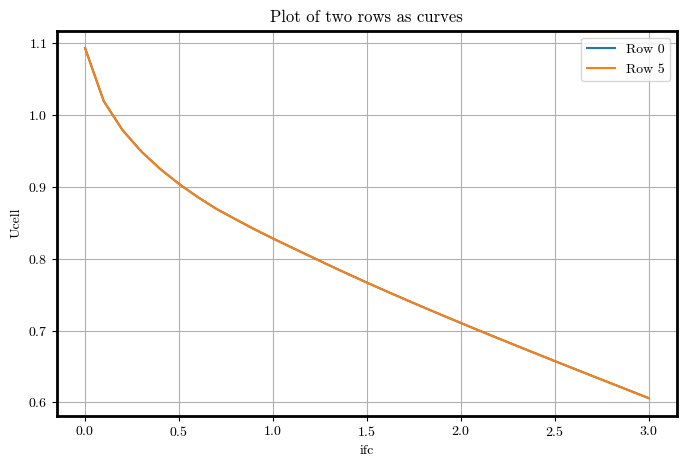

In [259]:
import matplotlib.pyplot as plt

x1 = subset.iloc[0]['ifc']
y1 = subset.iloc[0]['Ucell']

x2 = subset.iloc[5]['ifc']
y2 = subset.iloc[5]['Ucell']

plt.figure(figsize=(8,5))
plt.plot(x1, y1, label=f'Row {0}')
plt.plot(x2, y2, label=f'Row {5}')
plt.xlabel('ifc')
plt.ylabel('Ucell')
plt.title('Plot of two rows as curves')
plt.legend()
plt.grid(True)
plt.show()


We filter nathaly_all with the 4.450 indices of the original configuations

In [ ]:
nathaly_all_reviewed = all_nathaly_cmpl.iloc[indices_nathaly_all]
print(f' we validate the size {nathaly_all_reviewed.shape}')
# we write the file
pd.DataFrame(nathaly_all_reviewed).to_pickle("../sampling_test/nathaly4450_reviewed.pkl")

We define what indices are missing and we should run

In [ ]:
indices_cmpl= range(21836,28672)
indices_to_check = common_rows.index.to_list()
indices_missing =  set(indices_cmpl)-set(indices_to_check)
print(f'Missing indices: {len(indices_missing)}')
# we save the vector of indices for running later
np.save('../sampling_test/missing_configurations_indexes.npy', indices_missing)

Missing indices: 2386


We review the order of the indices to understand if there are some gaps between indices

In [175]:
indices_missing_sorted = sorted(indices_missing)
print(indices_missing_sorted)

[21836, 21837, 21838, 21839, 21840, 21841, 21842, 21843, 21845, 21846, 21847, 21848, 21849, 21852, 21854, 21856, 21857, 21858, 21860, 21861, 21863, 21864, 21865, 21866, 21870, 21871, 21872, 21874, 21875, 21876, 21878, 21879, 21882, 21883, 21884, 21885, 21888, 21889, 21891, 21892, 21893, 21894, 21896, 21898, 21900, 21902, 21903, 21904, 21905, 21906, 21907, 21908, 21910, 21912, 21913, 21914, 21917, 21919, 21921, 21922, 21925, 21926, 21928, 21930, 21933, 21934, 21935, 21939, 21940, 21941, 21942, 21943, 21944, 21945, 21946, 21947, 21948, 21949, 21950, 21951, 21952, 21953, 21954, 21955, 21956, 21957, 21959, 21961, 21962, 21963, 21964, 21965, 21966, 21967, 21969, 21970, 21972, 21973, 21974, 21975, 21976, 21977, 21978, 21979, 21980, 21981, 21982, 21983, 21984, 21986, 21987, 21988, 21989, 21990, 21991, 21994, 21995, 21996, 21997, 21998, 21999, 22000, 22001, 22002, 22006, 22007, 22009, 22010, 22011, 22012, 22014, 22016, 22018, 22019, 22020, 22022, 22023, 22025, 22026, 22027, 22028, 22029, 22030

In [130]:
28672-26664

2008

We verify from the total of configurations that we keep the same number registers that coincide

In [132]:

samples = samples.drop('Pc_des',axis=1)
# Drop index to avoid index mismatches
common_rows_cmpl = samples[samples.apply(tuple, axis=1).isin(all_nathaly.apply(tuple, axis=1))]

print("Matching rows:")
print(common_rows_cmpl)

Matching rows:
              Tfc         Pa_des        Sc  Phi_c_des  epsilon_gdl       tau  \
21844  335.658305  277201.591579  2.584250   0.497627     0.572730  1.867062   
21850  335.658305  277201.591579  2.584250   0.233144     0.572730  1.867062   
21851  335.658305  277201.591579  2.584250   0.233144     0.572730  1.867062   
21853  335.658305  277201.591579  2.584250   0.233144     0.572730  1.867062   
21855  357.744220  277201.591579  2.140921   0.497627     0.796952  3.691955   
...           ...            ...       ...        ...          ...       ...   
28667  340.898636  152452.823874  1.307282   0.283673     0.728948  1.935460   
28668  340.898636  152452.823874  1.307282   0.283673     0.728948  1.935460   
28669  340.898636  152452.823874  1.307282   0.283673     0.728948  1.935460   
28670  340.898636  152452.823874  1.307282   0.283673     0.728948  1.935460   
28671  340.898636  152452.823874  1.307282   0.283673     0.728948  1.935460   

       epsilon_mc  epsil

## Duplicates

In [176]:
duplicate_counts = samples.groupby(list(samples.columns)).size().reset_index(name='count')
# Filter to only rows that occur more than once
duplicate_counts = duplicate_counts[duplicate_counts['count'] > 1]


In [178]:
np.sum(duplicate_counts['count'])

np.int64(1332)

In [198]:
np.max(duplicate_counts['count'])

np.int64(2)

In [181]:
samples[samples.duplicated(keep=False)]

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c
56,349.763522,249912.013861,2.190848,0.363511,0.703380,2.321938,0.373490,0.217216,4,0.000005,19.200966,24.028647,0.080690
65,349.763522,249912.013861,2.190848,0.363511,0.703380,2.321938,0.373490,0.217216,4,0.000005,19.200966,24.028647,0.080690
78,357.023025,266488.179691,1.554174,0.636117,0.568659,1.741093,0.281141,0.168116,4,0.000004,63.904476,21.723357,0.832453
83,357.023025,266488.179691,1.554174,0.636117,0.568659,1.741093,0.281141,0.168116,4,0.000004,63.904476,21.723357,0.832453
84,334.344075,166509.169917,1.689764,0.406209,0.570114,3.046553,0.235166,0.290502,4,0.000003,61.711409,38.902536,1.618357
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28531,347.339113,237566.044861,1.680123,0.417527,0.764694,1.207560,0.270941,0.179113,5,0.000003,68.271106,22.834223,1.393961
28532,337.903351,207784.137656,2.858919,0.415234,0.574493,3.085855,0.375004,0.263141,3,0.000002,63.491835,35.274419,0.088496
28541,337.903351,207784.137656,2.858919,0.415234,0.574493,3.085855,0.375004,0.263141,3,0.000002,63.491835,35.274419,0.088496
28554,350.299049,186660.557851,2.596892,0.238588,0.616443,2.522971,0.309355,0.255397,3,0.000001,4.960361,39.570709,0.024423


In [186]:
for _, row in duplicate_counts.iloc[0:3].iterrows():
    # Create a boolean mask matching the duplicated row values
    mask = (samples[list(samples.columns)] == row[list(samples.columns)]).all(axis=1)
    indices = samples.index[mask].tolist()
    print(f"Duplicate row: {row[list(samples.columns)].to_dict()}")
    print(f"Indices in original df: {indices}")
    print(f"Count: {row['count']}\n")


Duplicate row: {'Tfc': 333.00469909098183, 'Pa_des': 275013.2571655251, 'Sc': 1.7676554993250035, 'Phi_c_des': 0.41458829600419844, 'epsilon_gdl': 0.6937818620530889, 'tau': 3.326169753359258, 'epsilon_mc': 0.3292855117871426, 'epsilon_c': 0.24880248595266602, 'e': 5.0, 'Re': 1.0839925570813009e-06, 'i0_c_ref': 27.43629878574056, 'kappa_co': 23.896869720071557, 'kappa_c': 1.1730914765815252}
Indices in original df: [15120, 15129]
Count: 2.0

Duplicate row: {'Tfc': 333.0567566687297, 'Pa_des': 130246.08156296983, 'Sc': 1.4648688884318062, 'Phi_c_des': 0.11177341395035387, 'epsilon_gdl': 0.5772937677343377, 'tau': 2.1321665183084084, 'epsilon_mc': 0.18654874168597163, 'epsilon_c': 0.2570793507469911, 'e': 5.0, 'Re': 4.962671001877636e-06, 'i0_c_ref': 59.09934629647803, 'kappa_co': 31.960600509042855, 'kappa_c': 2.486925101113506}
Indices in original df: [11390, 11395]
Count: 2.0

Duplicate row: {'Tfc': 333.08559621360337, 'Pa_des': 213842.14685932547, 'Sc': 1.2749924987429566, 'Phi_c_des

In [241]:
samples.iloc[15120:15136]

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c
15120,333.004699,275013.257166,1.767655,0.414588,0.693782,3.326170,0.329286,0.248802,5,0.000001,27.436299,23.896870,1.173091
15121,341.710069,275013.257166,1.767655,0.414588,0.693782,3.326170,0.329286,0.248802,5,0.000001,27.436299,23.896870,1.173091
15122,333.004699,247126.906746,1.767655,0.414588,0.693782,3.326170,0.329286,0.248802,5,0.000001,27.436299,23.896870,1.173091
15123,333.004699,275013.257166,2.453989,0.414588,0.693782,3.326170,0.329286,0.248802,5,0.000001,27.436299,23.896870,1.173091
15124,333.004699,275013.257166,1.767655,0.454762,0.693782,3.326170,0.329286,0.248802,5,0.000001,27.436299,23.896870,1.173091
15125,333.004699,275013.257166,1.767655,0.414588,0.621115,3.326170,0.329286,0.248802,5,0.000001,27.436299,23.896870,1.173091
15126,333.004699,275013.257166,1.767655,0.414588,0.693782,2.303831,0.329286,0.248802,5,0.000001,27.436299,23.896870,1.173091
15127,333.004699,275013.257166,1.767655,0.414588,0.693782,3.326170,0.386916,0.248802,5,0.000001,27.436299,23.896870,1.173091
15128,333.004699,275013.257166,1.767655,0.414588,0.693782,3.326170,0.329286,0.228304,5,0.000001,27.436299,23.896870,1.173091
15129,333.004699,275013.257166,1.767655,0.414588,0.693782,3.326170,0.329286,0.248802,5,0.000001,27.436299,23.896870,1.173091


In [ ]:
row = samples.iloc[15129]

# Compare row-wise
duplicate_counts2 = duplicate_counts.drop('count',axis=1)
matches = (duplicate_counts2 == row).all(axis=1)

# Get the index/indices where the row matches
matching_indices = duplicate_counts2.index[matches]

print(matching_indices)


Index([], dtype='int64')


In [250]:
row = samples.loc[15129]
matches = (samples == row).all(axis=1)
print(f'{matches[matches == True].index.tolist()}')
row = samples.loc[15130]
matches = (samples == row).all(axis=1)
print(f'{matches[matches == True].index.tolist()}')

[15120, 15129]
[15130]
